In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob              # sentiment analysis
from wordcloud import WordCloud            # creating word cloud

In [2]:
df = pd.read_csv(r"D:\Data Analyst\Project\python_sentiments\Banking_Sentiment\banking_feedback.csv")

In [3]:
df.head()

,Sentences
0,Transaction search filters don’t work properly.
1,I loved the cashback I received on my utility ...
2,Loan disbursal was quick and required minimal ...
3,The auto-pay feature didn’t work and led to pe...
4,Refund from a failed transaction took more tha...


In [4]:
df.shape

print("Total number of feedbacks: ", df.shape[0])

Total number of feedbacks:  110


In [5]:
# Define the sentiment analysis function

def get_sentiment(text):
    meaning = TextBlob(text)

    if meaning.sentiment.polarity > 0 :
        return "Positive"
    elif meaning.sentiment.polarity < 0 :
        return "Negative"
    else:
        return "Neutral"

In [6]:
# Apply the sentiment analysis function to the "Sentences" column and create a new column "Sentiment"

df["Sentiment"] = df["Sentences"].apply(get_sentiment)

In [7]:
df.head()

,Sentences,Sentiment
0,Transaction search filters don’t work properly.,Neutral
1,I loved the cashback I received on my utility ...,Positive
2,Loan disbursal was quick and required minimal ...,Positive
3,The auto-pay feature didn’t work and led to pe...,Neutral
4,Refund from a failed transaction took more tha...,Neutral


In [8]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Neutral     48
Positive    39
Negative    23
Name: count, dtype: int64


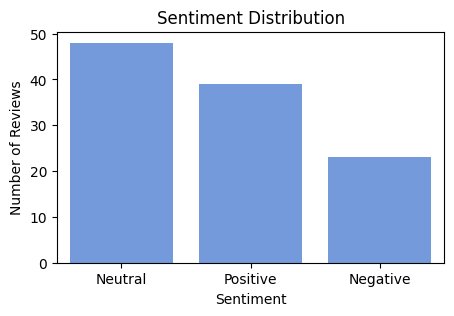

In [9]:
plt.figure(figsize=(5,3))

sns.countplot(x = "Sentiment",data= df,color = "cornflowerblue")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

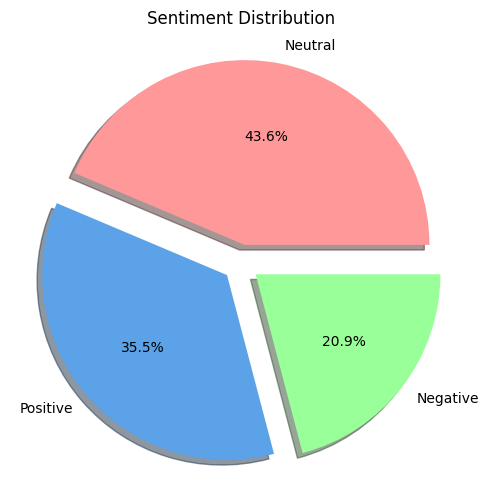

In [10]:
plt.figure(figsize=(6,6))

df["Sentiment"].value_counts().plot(kind = "pie",autopct = "%1.1f%%",shadow = True,explode = [0.1,0.1,0.1],colors = ["#ff9999","#5ba2e9","#99ff99"])
plt.title("Sentiment Distribution")
plt.ylabel("")
plt.show()

In [11]:
negative_reviews = df[df["Sentiment"] == "Negative"]

negative_reviews.head()

,Sentences,Sentiment
10,The credit score section shows outdated inform...,Negative
11,The bank took too long to issue a closure cert...,Negative
22,Customer service representatives were rude and...,Negative
24,The foreign transaction process was hassle-fre...,Negative
30,My loan balance wasn’t updated after partial p...,Negative


In [12]:
# Combine all negative reviews into a single string

negative_text = " ".join(negative_reviews["Sentences"])

In [13]:
print(negative_text)


The credit score section shows outdated information. The bank took too long to issue a closure certificate. Customer service representatives were rude and unhelpful. The foreign transaction process was hassle-free and transparent. My loan balance wasn’t updated after partial prepayment. EMI payment reminders are timely and help me avoid late fees. The EMI auto-debit failed despite sufficient balance. The loan approval process was unnecessarily complicated. Customer service took too long to answer my call. I faced delays in loan disbursal due to missing communication. The UPI transaction failed but the amount was still debited. Loan officer arrived late and missed our appointment. I was charged a late fee even though I paid on time. The mobile app login often fails due to server issues. I didn’t receive any acknowledgment after raising a complaint. My card replacement request was fulfilled earlier than expected. Customer service was extremely polite and helped me understand my credit sc

In [14]:
# Word Cloud for Negative Reviews

negative_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

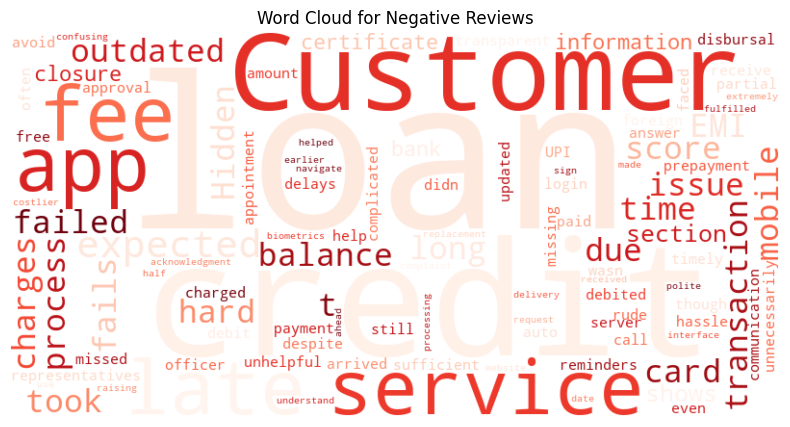

In [15]:
# Create a word cloud for negative reviews

plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Negative Reviews")
plt.show()

In [16]:
positive_reviews = df[df["Sentiment"] == "Positive"]

positive_reviews.head()

,Sentences,Sentiment
1,I loved the cashback I received on my utility ...,Positive
2,Loan disbursal was quick and required minimal ...,Positive
6,The bank’s response time on email queries is v...,Positive
9,The account opening process was smooth and too...,Positive
12,The loan application process was seamless and ...,Positive


In [17]:
# Combine all Positive reviews into a single string

positive_text = " ".join(positive_reviews["Sentences"])

In [18]:
# Word Cloud for Positive Reviews

positive_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positive_text)

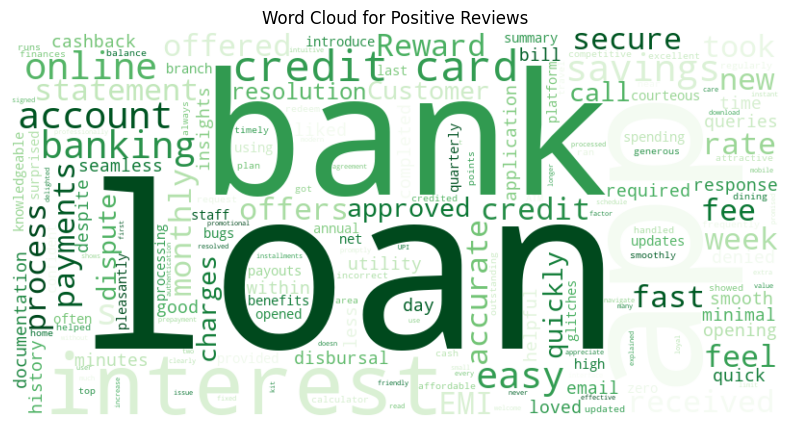

In [19]:
# Create a word cloud for positive reviews

plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Positive Reviews")
plt.show()

In [20]:
neutral_reviews = df[df["Sentiment"] == "Neutral"]

neutral_reviews.head()

,Sentences,Sentiment
0,Transaction search filters don’t work properly.,Neutral
3,The auto-pay feature didn’t work and led to pe...,Neutral
4,Refund from a failed transaction took more tha...,Neutral
5,My transaction history shows duplicate entries.,Neutral
7,The branch staff were unhelpful and dismissive...,Neutral


In [21]:
# Combine all Neutral reviews into a single string

neutral_text = " ".join(neutral_reviews["Sentences"])

In [22]:
# Word Cloud for Neutral Reviews

neutral_wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(neutral_text)

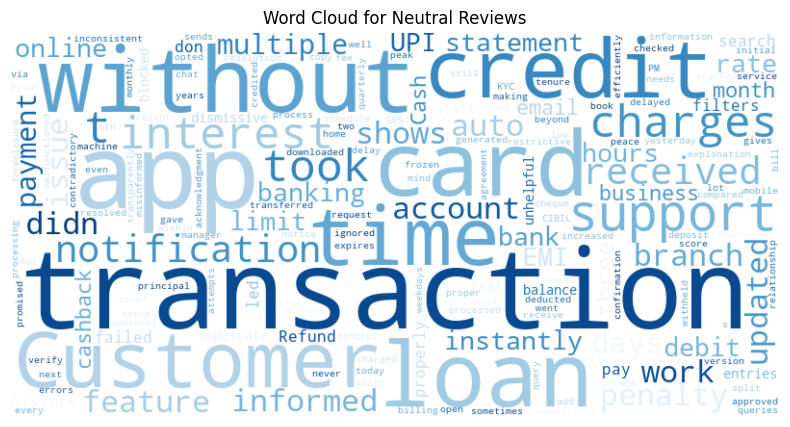

In [23]:
# Create a word cloud for Neutral reviews

plt.figure(figsize=(10, 5))
plt.imshow(neutral_wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud for Neutral Reviews")
plt.show()

In [24]:
df.to_csv("banking_sentiment_feedback.csv", index = False)